# ASR with Free Spoken Digit Dataset Tutorial

#### For AI Engineering (Fundamental) Class
#### By Dr. Ye Kyaw Thu, Lab Leader, Language Understanding Lab, AI Mario, Myanmar  

အခုအချိန်မှာ End-to-End ASR ဘက်ကိုသွားနေကြပေမဲ့ တကယ်တမ်း ASR R&D နဲ့ speech engineering ကို သိချင်၊ တတ်ချင်တဲ့ ကျောင်းသားတွေက Kaldi framework ကို မသိလို့မဖြစ်ဘူး။ အဲဒါကြောင့် ဒီ Tutorial no. 2 ကိုလည်း အသေအချာ လိုက်လုပ်ကြည့်ကြပါလို့ တိုက်တွန်းပါတယ်။  


Homepage of Kaldi: [https://kaldi-asr.org/](https://kaldi-asr.org/)  
Documentation of Kaldi: [https://kaldi-asr.org/doc/index.html](https://kaldi-asr.org/doc/index.html)  
Free Spoken Digit Dataset (FSDD): [https://github.com/Jakobovski/free-spoken-digit-dataset](https://github.com/Jakobovski/free-spoken-digit-dataset)  


## Python - Setup Environment & Paths

In [74]:
import os

# 1. Define the root of your Kaldi installation and the new demo path
kaldi_root = "/mnt/disk1/ye/exp/speech/kaldi"
recipe_path = os.path.join(kaldi_root, "egs/fsdd_demo/s5")

# 2. Set KALDI_ROOT
os.environ["KALDI_ROOT"] = kaldi_root

# 3. Add all necessary Kaldi binary paths to the system PATH
paths_to_add = [
    os.path.join(recipe_path, "utils"),
    os.path.join(recipe_path, "steps"),
    recipe_path,
    os.path.join(kaldi_root, "tools/openfst/bin"),
    os.path.join(kaldi_root, "src/featbin"),
    os.path.join(kaldi_root, "src/gmmbin"),
    os.path.join(kaldi_root, "src/bin"),
    os.path.join(kaldi_root, "src/fstbin"),
    os.path.join(kaldi_root, "src/lmbin"),
    os.path.join(kaldi_root, "src/decoderbin"),
    os.path.join(kaldi_root, "src/nnet3bin"),
    os.path.join(kaldi_root, "src/ivectorbin"),
    os.path.join(kaldi_root, "src/online2bin")
]

current_path = os.environ.get("PATH", "")
os.environ["PATH"] = ":".join(paths_to_add) + ":" + current_path

print("KALDI_ROOT:", os.environ.get("KALDI_ROOT"))
print("Setup Complete. Paths added to environment.")

KALDI_ROOT: /mnt/disk1/ye/exp/speech/kaldi
Setup Complete. Paths added to environment.


In [76]:
%cd

/home/ye


## Step 0: Bash - Download Data & Copy Kaldi Scripts

In [77]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo

# Create new s5 directory
mkdir s5
cd s5

# Clean up previous runs
rm -rf data exp mfcc recordings

# Copy standard Kaldi utility scripts from the yesno recipe
cp -r ../../yesno/s5/utils .
cp -r ../../yesno/s5/steps .
cp -r ../../yesno/s5/conf .
cp -r ../../yesno/s5/local .

In [78]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# Clone the Free Spoken Digit Dataset from GitHub
time git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

# The audio files are inside the 'recordings' folder
ln -s free-spoken-digit-dataset/recordings recordings

echo "=== Dataset Downloaded ==="
ls recordings | head -n 5

Cloning into 'free-spoken-digit-dataset'...

real	0m4.086s
user	0m1.213s
sys	0m0.287s


=== Dataset Downloaded ===
0_george_0.wav
0_george_10.wav
0_george_11.wav
0_george_12.wav
0_george_13.wav


In [81]:
%cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

/mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5


In [82]:
# Import the Audio display class
from IPython.display import Audio

wav_file = "./recordings/0_george_12.wav"
display(Audio(filename=wav_file))

In [83]:
# Import the Audio display class
from IPython.display import Audio

wav_file = "./recordings/7_george_0.wav"
display(Audio(filename=wav_file))

## Step 1: Data Preparation (Custom for FSDD)

FSDD ဒေတာရဲ့ ဖိုင်နာမည်တွေကို လေ့လာကြည့်တော့ ဥပမာ "0_jackson_0.wav" ဆိုပြီး ပေးထားတာမို့၊ ပထမဆုံးက ဘယ်နံပါတ်ဆိုတဲ့ အပိုင်း၊ ပြီးတော့မှ စကားပြောသူရဲ့ နာမည် နဲ့ နောက်ဆုံးပိုင်းမှာက ရီကောဒင်းအကြိမ်အရေအတွက် ဆိုတဲ့ "Digit_Speaker_Index" ပုံစံနဲ့ သိမ်းဆည်းထားတာကိုတွေ့ရပါတယ်။ အောက်ပါ ကုဒ်ကတော့ FSDD ဖိုင်နာမည်ပုံစံကနေ က လိုအပ်တဲ့ ဒေတာဖိုင်တွေအဖြစ် ပြောင်းပေးတဲ့အပိုင်းပါ။

Training အတွက် speaker လေးယောက်ထားလိုက်ပြီး၊ testing အတွက်ကတော့ speaker နှစ်ယောက်ထားကြရအောင်။  


In [84]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# Prepare directories
mkdir -p data/train data/test

# Clear previous files
rm -f data/train/* data/test/*

# Define speakers for train and test
train_spks="jackson lucas nicolas yweweler"
test_spks="george theo"

# Map digit numbers to words
declare -A digit_words
digit_words[0]="zero"; digit_words[1]="one"; digit_words[2]="two"; digit_words[3]="three"; digit_words[4]="four"
digit_words[5]="five"; digit_words[6]="six"; digit_words[7]="seven"; digit_words[8]="eight"; digit_words[9]="nine"

# Loop through all wav files
for wav in recordings/*.wav; do
  filename=$(basename "$wav" .wav) # e.g., 0_jackson_0
  IFS='_' read -r digit speaker index <<< "$filename"
  
  # Kaldi requires utterance IDs to be unique. We format them as speaker_digit_index
  utt_id="${speaker}_${digit}_${index}"
  word=${digit_words[$digit]}
  wav_path=$(pwd)/$wav
  
  # Assign to train or test based on speaker
  if [[ " $train_spks " =~ " $speaker " ]]; then
    dir="data/train"
  elif [[ " $test_spks " =~ " $speaker " ]]; then
    dir="data/test"
  else
    continue
  fi
  
  # Populate Kaldi text files
  echo "$utt_id $speaker" >> $dir/utt2spk
  echo "$speaker $utt_id" >> $dir/spk2utt
  echo "$utt_id $word" >> $dir/text
  echo "$utt_id $wav_path" >> $dir/wav.scp
done

# Kaldi requires files to be sorted
for x in train test; do
  dir=data/$x
  sort -o $dir/utt2spk $dir/utt2spk
  sort -o $dir/spk2utt $dir/spk2utt
  sort -o $dir/text $dir/text
  sort -o $dir/wav.scp $dir/wav.scp
  
  # Validate and fix data directory
  utils/fix_data_dir.sh $dir
done

echo "=== Data Preparation Complete ==="
echo "Train utterances: $(wc -l < data/train/text)"
echo "Test utterances: $(wc -l < data/test/text)"

utils/fix_data_dir.sh: file data/train/utt2spk is not in sorted order or not unique, sorting it
utils/fix_data_dir.sh: file data/train/spk2utt is not in sorted order or not unique, sorting it
utils/fix_data_dir.sh: file data/train/text is not in sorted order or not unique, sorting it
utils/fix_data_dir.sh: file data/train/wav.scp is not in sorted order or not unique, sorting it
fix_data_dir.sh: kept all 2000 utterances.
fix_data_dir.sh: old files are kept in data/train/.backup
utils/fix_data_dir.sh: file data/test/utt2spk is not in sorted order or not unique, sorting it
utils/fix_data_dir.sh: file data/test/spk2utt is not in sorted order or not unique, sorting it
utils/fix_data_dir.sh: file data/test/text is not in sorted order or not unique, sorting it
utils/fix_data_dir.sh: file data/test/wav.scp is not in sorted order or not unique, sorting it
fix_data_dir.sh: kept all 1000 utterances.
fix_data_dir.sh: old files are kept in data/test/.backup
=== Data Preparation Complete ===
Train u

#### Test set ထဲက audio တစ်ဖိုင်လောက်ကို နားထောင်ကြည့်ရအောင်။  

In [85]:
from IPython.display import Audio, display
import subprocess

recipe_path = "/mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5"

# Read the wav.scp file to get the path of the first test audio file
with open(f"{recipe_path}/data/test/wav.scp", "r") as f:
    first_line = f.readline()
    audio_path = first_line.split(" ")[-1].strip()

# Get the transcript for this utterance
utt_id = first_line.split(" ")[0]
transcript = subprocess.check_output(f"grep {utt_id} {recipe_path}/data/test/text", shell=True).decode().strip()
print(f"Transcript: {transcript}")
print(f"Audio file path: {audio_path}")
print("Listen to the audio:")
display(Audio(audio_path))

Transcript: george_0_0 zero
Audio file path: /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5/recordings/0_george_0.wav
Listen to the audio:


## Step 2: Dictionary & Language Model Preparation

အင်္ဂလိပ် နံပါတ် သုည ကနေ ကိုး အတွက် Pronunciation dictionary ကို ဆောက်ကြရလိမ့်မယ်။ အဘိဓာန် အသေးလေးမို့ manual ရိုက်ထည့်ပြီး ပြင်ဆင်လို့လည်း ရပါတယ်။ အင်္ဂလိပ်စာအတွက်က စံအဖြစ်သတ်မှတ်ထားတဲ့ ARPABET phonemes ဆိုတာရှိတာမို့ အဲဒါကိုပဲ ယူပြီးဆောက်ပါမယ်။ ပြီးရင်တော့ Finite State Transducer နှစ်ခုဖြစ်တဲ့ L.fst (i.e. Lexicon) နဲ့ G.fst (i.e. a simple unigram Grammar) ကိုလည်း ဆောက်ပါမယ်။  

In [86]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# FIX 1: Copy path.sh from yesno recipe so Kaldi scripts can find OpenFst tools
cp ../../yesno/s5/path.sh .

mkdir -p data/local/dict

# 1. Create the Lexicon (words mapped to phonemes)
cat << 'EOF' | sort > data/local/dict/lexicon.txt
<SIL> SIL
eight EY T
five F AY V
four F AO R
nine N AY N
one W AH N
seven S EH V AH N
six S IH K S
three TH R IY
two T UW
zero Z IY R OW
EOF

# 2. Define phoneme lists
echo "SIL" > data/local/dict/silence_phones.txt
echo "SIL" > data/local/dict/optional_silence.txt

cat << 'EOF' | sort > data/local/dict/nonsilence_phones.txt
AH
AO
AY
EH
EY
F
IH
IY
K
N
OW
R
S
T
TH
UW
V
W
Z
EOF

# Clean up previous failed attempts
# rm -rf data/lang data/local/lang

# 3. Prepare the Lang directory (builds L.fst)
utils/prepare_lang.sh --position-dependent-phones false \
  data/local/dict "<SIL>" data/local/lang data/lang

# 4. Build a simple unigram Language Model (G.fst) based on word counts in training
cat data/train/text | awk '{print $2}' | sort | uniq -c | \
  awk '{print $2, $1}' > data/local/word_counts.txt

# FIX 2: Pipe the word counts file into the Perl script via standard input
cat data/local/word_counts.txt | utils/make_unigram_grammar.pl > data/lang/G.fst

echo "=== Dictionary & Lang Prep Complete ==="
ls data/lang/

utils/prepare_lang.sh --position-dependent-phones false data/local/dict <SIL> data/local/lang data/lang
Checking data/local/dict/silence_phones.txt ...
--> reading data/local/dict/silence_phones.txt
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/local/dict/silence_phones.txt is OK

Checking data/local/dict/optional_silence.txt ...
--> reading data/local/dict/optional_silence.txt
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/local/dict/optional_silence.txt is OK

Checking data/local/dict/nonsilence_phones.txt ...
--> reading data/local/dict/nonsilence_phones.txt
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/local/dict/nonsilence_phones.txt is OK

Checking disjoint: silence_phones.txt, nonsilence_phones.txt
--> disjoint property is OK.

Checking data/local/dict/lexicon.txt
--> reading data/local/dict

fstaddselfloops data/lang/phones/wdisambig_phones.int data/lang/phones/wdisambig_words.int 


prepare_lang.sh: validating output directory
utils/validate_lang.pl data/lang
Checking existence of separator file
separator file data/lang/subword_separator.txt is empty or does not exist, deal in word case.
Checking data/lang/phones.txt ...
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/lang/phones.txt is OK

Checking words.txt: #0 ...
--> text seems to be UTF-8 or ASCII, checking whitespaces
--> text contains only allowed whitespaces
--> data/lang/words.txt is OK

Checking disjoint: silence.txt, nonsilence.txt, disambig.txt ...
--> silence.txt and nonsilence.txt are disjoint
--> silence.txt and disambig.txt are disjoint
--> disambig.txt and nonsilence.txt are disjoint
--> disjoint property is OK

Checking sumation: silence.txt, nonsilence.txt, disambig.txt ...
--> found no unexplainable phones in phones.txt

Checking data/lang/phones/context_indep.{txt, int, csl} ...
--> text seems to be UTF-8 or ASCII, checking whitespa

#### ဖတ်လို့ရတဲ့ text-ဖိုင်တွေကို လေ့လာကြည့်ရအောင်။  

In [87]:
!ls ./data/lang

G.fst		L.fst	 oov.txt  phones.txt  words.txt
L_disambig.fst	oov.int  phones   topo


In [88]:
!cat ./data/lang/oov.txt

<SIL>


In [89]:
!cat ./data/lang/oov.int

1


In [90]:
!cat ./data/lang/phones.txt

<eps> 0
SIL 1
AH 2
AO 3
AY 4
EH 5
EY 6
F 7
IH 8
IY 9
K 10
N 11
OW 12
R 13
S 14
T 15
TH 16
UW 17
V 18
W 19
Z 20
#0 21
#1 22


In [91]:
!cat ./data/lang/words.txt

<eps> 0
<SIL> 1
eight 2
five 3
four 4
nine 5
one 6
seven 7
six 8
three 9
two 10
zero 11
#0 12
<s> 13
</s> 14


In [92]:
!ls ./data/lang/phones

align_lexicon.int    extra_questions.txt   sets.int
align_lexicon.txt    nonsilence.csl	   sets.txt
context_indep.csl    nonsilence.int	   silence.csl
context_indep.int    nonsilence.txt	   silence.int
context_indep.txt    optional_silence.csl  silence.txt
disambig.csl	     optional_silence.int  wdisambig_phones.int
disambig.int	     optional_silence.txt  wdisambig.txt
disambig.txt	     roots.int		   wdisambig_words.int
extra_questions.int  roots.txt


In [93]:
!cat ./data/lang/phones/disambig.txt

#0
#1


In [94]:
!cat ./data/lang/phones/extra_questions.txt

In [95]:
!cat ./data/lang/phones/optional_silence.txt

SIL


In [96]:
!ls ./data/local/lang

align_lexicon.txt      lexiconp.txt   phone_map.txt
lexiconp_disambig.txt  lex_ndisambig  phones


In [97]:
!cat ./data/local/lang/align_lexicon.txt

eight EY T
five F AY V
four F AO R
nine N AY N
one W AH N
seven S EH V AH N
<SIL> SIL
six S IH K S
three TH R IY
two T UW
zero Z IY R OW
<eps> SIL


In [98]:
!cat ./data/local/lang/lexiconp_disambig.txt

eight	1.0	EY T
five	1.0	F AY V
four	1.0	F AO R
nine	1.0	N AY N
one	1.0	W AH N
seven	1.0	S EH V AH N
<SIL>	1.0	SIL
six	1.0	S IH K S
three	1.0	TH R IY
two	1.0	T UW
zero	1.0	Z IY R OW


In [99]:
!cat ./data/local/lang/lexiconp.txt

eight 1.0	EY T
five 1.0	F AY V
four 1.0	F AO R
nine 1.0	N AY N
one 1.0	W AH N
seven 1.0	S EH V AH N
<SIL> 1.0	SIL
six 1.0	S IH K S
three 1.0	TH R IY
two 1.0	T UW
zero 1.0	Z IY R OW


In [100]:
!cat ./data/local/lang/phone_map.txt

SIL SIL
AH AH
AO AO
AY AY
EH EH
EY EY
F F
IH IH
IY IY
K K
N N
OW OW
R R
S S
T T
TH TH
UW UW
V V
W W
Z Z


## Step 3: Feature Extraction (MFCC)

Training/Testing နှစ်မျိုးစလုံးအတွက် Mel-Frequency Cepstral Coefficients (MFCCs) ထုတ်ကြရအောင်။   

In [101]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

mfccdir=mfcc
for x in test train; do
  steps/make_mfcc.sh --cmd "utils/run.pl" --nj 10 data/$x exp/make_mfcc/$x $mfccdir || exit 1;
  steps/compute_cmvn_stats.sh data/$x exp/make_mfcc/$x $mfccdir || exit 1;
  utils/fix_data_dir.sh data/$x
done

echo "=== MFCC Feature Extraction Complete ==="
ls mfcc/

steps/make_mfcc.sh --cmd utils/run.pl --nj 10 data/test exp/make_mfcc/test mfcc
utils/validate_data_dir.sh: Successfully validated data-directory data/test
steps/make_mfcc.sh: [info]: no segments file exists: assuming wav.scp indexed by utterance.
steps/make_mfcc.sh: Succeeded creating MFCC features for test
steps/compute_cmvn_stats.sh data/test exp/make_mfcc/test mfcc
Succeeded creating CMVN stats for test
fix_data_dir.sh: kept all 1000 utterances.
fix_data_dir.sh: old files are kept in data/test/.backup
steps/make_mfcc.sh --cmd utils/run.pl --nj 10 data/train exp/make_mfcc/train mfcc
utils/validate_data_dir.sh: Successfully validated data-directory data/train
steps/make_mfcc.sh: [info]: no segments file exists: assuming wav.scp indexed by utterance.
steps/make_mfcc.sh: Succeeded creating MFCC features for train
steps/compute_cmvn_stats.sh data/train exp/make_mfcc/train mfcc
Succeeded creating CMVN stats for train
fix_data_dir.sh: kept all 2000 utterances.
fix_data_dir.sh: old files a

## Step 4: Train Monophone Model  

ဒီ tutorial မှာတော့ မော်ဒယ်နှစ်မျိုးဆောက်ပါမယ်။ ပထမဆုံး baseline မော်ဒယ်ဖြစ်တဲ့ Monophone GMM-HMM မော်ဒယ်ကို ဆောက်ပါမယ်။ FSDD ဒေတာမှာက training utterance က နှစ်ထောင်လောက်ပဲ ရှိတာမို့ ASR model အနေနဲ့ဆိုရင် ဒေတာပမာဏက နည်းပါတယ်။ အဲဒါကြောင့် CPU မှာပဲ ဆောက်ရင်တောင်မှ အပိုင်းအသေးလေးတွေ ပိုင်းပြီးမှ ဆောက်တာမျိုး လုပ်ဖို့ မလိုပါဘူး။  

In [102]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

time steps/train_mono.sh --nj 4 --cmd "utils/run.pl" \
  data/train data/lang exp/mono0a

echo "=== Monophone Training Complete ==="
ls exp/mono0a/final.mdl

steps/train_mono.sh --nj 4 --cmd utils/run.pl data/train data/lang exp/mono0a
steps/train_mono.sh: Initializing monophone system.
steps/train_mono.sh: Compiling training graphs
steps/train_mono.sh: Aligning data equally (pass 0)
steps/train_mono.sh: Pass 1
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 2
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 3
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 4
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 5
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 6
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 7
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 8
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 9
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 10
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 11
steps/train_mono.sh: Pass 12
steps/train_mono.sh: Aligning data
steps/train_mono.sh: Pass 13
steps/train_mono.s


real	0m8.598s
user	0m20.448s
sys	0m6.818s


=== Monophone Training Complete ===
exp/mono0a/final.mdl


## Step 5: Decode & Evaluate Monophone  

အထက်မှာ `make_unigram_grammar.pl` ကုဒ်နဲ့ ဆရာတို့ ဆောက်ခဲ့တဲ့ G.fst က text ဖိုင်ပါ။ ခုနောက်တစ်ဆင့် ဂရဖ်ဆောက်ဖို့အတွက် သုံးမယ့် `mkgraph.sh`  က သုံးမှာက binary format ပြောင်းထားတဲ့ FST ဖိုင်မို့လို့ ဆရာတို့ text ---> binary ကို ပြောင်းပေးဖို့ လိုအပ်တယ်။  


In [103]:
!cat data/lang/G.fst

0	0	eight	eight	3.40119738166216
0	0	nine	nine	3.40119738166216
0	0	five	five	3.40119738166216
0	0	six	six	3.40119738166216
0	0	two	two	3.40119738166216
0	0	200	200	1.09861228866811
0	0	seven	seven	3.40119738166216
0	0	one	one	3.40119738166216
0	0	four	four	3.40119738166216
0	0	three	three	3.40119738166216
0	0	zero	zero	3.40119738166216
0	1.09861228866811


**တကယ်က perl script ကို ဆရာဝင်ဖတ်ကြည့်တော့ ဆရာတို့ ပေးခဲ့တဲ့ input format မှာ မှားသွားတာ။ ပထမ column ဖြစ်တဲ့ "utterance ID" ကိုကျော်လိုက်ရင် ရပြီ။**  


In [104]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# 1. Pass the raw transcripts to the Perl script (skip utterance ID in column 1)
# The Perl script will automatically count the words and calculate the probabilities!
awk '{$1=""; print}' data/train/text | utils/make_unigram_grammar.pl > data/lang/G.txt

# 2. Compile the text FST into a binary FST using the words.txt symbol table
fstcompile --isymbols=data/lang/words.txt --osymbols=data/lang/words.txt \
  --keep_isymbols=false --keep_osymbols=false data/lang/G.txt | \
  fstarcsort --sort_type=ilabel > data/lang/G.fst

echo "=== G.fst successfully generated and compiled as binary ==="

=== G.fst successfully generated and compiled as binary ===


G.fst ဖိုင်ပြဿနာ မရှိတော့ဘူးလို့ ယုံကြည်တယ်။  

#### HCLG decoding graph ကိုဆောက်လိုက်ပြီး monophone model ကို testing လုပ်ကြည့်မယ်။  

In [105]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# Build decoding graph
utils/mkgraph.sh data/lang exp/mono0a exp/mono0a/graph

# FIX 2: Decode test set using --nj 2 (because FSDD test set only has 2 speakers)
steps/decode.sh --nj 2 --cmd "utils/run.pl" \
  exp/mono0a/graph data/test exp/mono0a/decode

echo "=== Monophone Evaluation Results ==="
grep WER exp/mono0a/decode/wer_* | utils/best_wer.sh

tree-info exp/mono0a/tree 
tree-info exp/mono0a/tree 
fsttablecompose data/lang/L_disambig.fst data/lang/G.fst 
fstminimizeencoded 
fstpushspecial 
fstdeterminizestar --use-log=true 
fstisstochastic data/lang/tmp/LG.fst 


0.000132889 0.000106158


fstcomposecontext --context-size=1 --central-position=0 --read-disambig-syms=data/lang/phones/disambig.int --write-disambig-syms=data/lang/tmp/disambig_ilabels_1_0.int data/lang/tmp/ilabels_1_0.906181 data/lang/tmp/LG.fst 
fstisstochastic data/lang/tmp/CLG_1_0.fst 


0.000132889 0.000106158


make-h-transducer --disambig-syms-out=exp/mono0a/graph/disambig_tid.int --transition-scale=1.0 data/lang/tmp/ilabels_1_0 exp/mono0a/tree exp/mono0a/final.mdl 
fstrmepslocal 
fstminimizeencoded 
fsttablecompose exp/mono0a/graph/Ha.fst data/lang/tmp/CLG_1_0.fst 
fstrmsymbols exp/mono0a/graph/disambig_tid.int 
fstdeterminizestar --use-log=true 
fstisstochastic exp/mono0a/graph/HCLGa.fst 


0.000244382 -0.000354668


add-self-loops --self-loop-scale=0.1 --reorder=true exp/mono0a/final.mdl exp/mono0a/graph/HCLGa.fst 


steps/decode.sh --nj 2 --cmd utils/run.pl exp/mono0a/graph data/test exp/mono0a/decode
decode.sh: feature type is delta
steps/diagnostic/analyze_lats.sh --cmd utils/run.pl exp/mono0a/graph exp/mono0a/decode
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 11.9% of the time at utterance begin.  This may not be optimal.
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 15.847542627883652% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_lats.sh: see stats in exp/mono0a/decode/log/analyze_alignments.log
Overall, lattice depth (10,50,90-percentile)=(1,1,3) and mean=1.4
steps/diagnostic/analyze_lats.sh: see stats in exp/mono0a/decode/log/analyze_lattice_depth_stats.log
local/score.sh --cmd utils/run.pl data/test exp/mono0a/graph exp/mono0a/decode
local/score.sh: scoring with word insertion penalty=0.0,0.5,1.0
=== Monophone Evaluation Results ===
%WER 14.10 [ 141 / 1000, 23 ins, 5 del, 113 sub ] exp/mono0a/decod

အထက်ပါအတိုင်း WER 14.10 ရတာကိုတွေ့ရတယ်။  

##  Step 6: Alignment

Align the training audio using the monophone model to prepare for triphone training.

In [106]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

steps/align_si.sh --nj 4 --cmd "utils/run.pl" \
  data/train data/lang exp/mono0a exp/mono0a_ali

echo "=== Alignment Complete ==="
ls exp/mono0a_ali/ali.1.gz

steps/align_si.sh --nj 4 --cmd utils/run.pl data/train data/lang exp/mono0a exp/mono0a_ali
steps/align_si.sh: feature type is delta
steps/align_si.sh: aligning data in data/train using model from exp/mono0a, putting alignments in exp/mono0a_ali
steps/diagnostic/analyze_alignments.sh --cmd utils/run.pl data/lang exp/mono0a_ali
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 23.1% of the time at utterance begin.  This may not be optimal.
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 12.45% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_alignments.sh: see stats in exp/mono0a_ali/log/analyze_alignments.log
steps/align_si.sh: done aligning data.
=== Alignment Complete ===
exp/mono0a_ali/ali.1.gz


## Step 7: Train Triphone Model
Train a context-dependent Triphone GMM-HMM. We use a smaller number of leaves (200) and Gaussians (2000) because the dataset is small.

In [108]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

time steps/train_deltas.sh --cmd "utils/run.pl" \
  200 2000 data/train data/lang exp/mono0a_ali exp/tri1

echo "=== Triphone Training Complete ==="
ls exp/tri1/final.mdl

steps/train_deltas.sh --cmd utils/run.pl 200 2000 data/train data/lang exp/mono0a_ali exp/tri1
steps/train_deltas.sh: accumulating tree stats
steps/train_deltas.sh: getting questions for tree-building, via clustering
steps/train_deltas.sh: building the tree
steps/train_deltas.sh: converting alignments from exp/mono0a_ali to use current tree
steps/train_deltas.sh: compiling graphs of transcripts
steps/train_deltas.sh: training pass 1
steps/train_deltas.sh: training pass 2
steps/train_deltas.sh: training pass 3
steps/train_deltas.sh: training pass 4
steps/train_deltas.sh: training pass 5
steps/train_deltas.sh: training pass 6
steps/train_deltas.sh: training pass 7
steps/train_deltas.sh: training pass 8
steps/train_deltas.sh: training pass 9
steps/train_deltas.sh: training pass 10
steps/train_deltas.sh: aligning data
steps/train_deltas.sh: training pass 11
steps/train_deltas.sh: training pass 12
steps/train_deltas.sh: training pass 13
steps/train_deltas.sh: training pass 14
steps/train_de


real	0m5.992s
user	0m11.088s
sys	0m5.112s


exp/tri1/final.mdl


## Step 8: Final Decode & Evaluation
Decode the test set with the Triphone model and compare the Word Error Rate (WER) to the Monophone model.

In [110]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# 1. Remove the failed/empty triphone decode directory
rm -rf exp/tri1/decode

# 2. Decode test set using --nj 2 (because FSDD test set only has 2 speakers)
steps/decode.sh --nj 2 --cmd "utils/run.pl" \
  exp/tri1/graph data/test exp/tri1/decode

# 3. Explicitly run the scoring script for the triphone model
local/score.sh --cmd "utils/run.pl" data/test data/lang exp/tri1/decode

echo "========================================="
echo "FINAL EVALUATION RESULTS"
echo "========================================="
echo "Monophone WER:"
grep WER exp/mono0a/decode/wer_* | utils/best_wer.sh

echo "-----------------------------------------"
echo "Triphone WER:"
grep WER exp/tri1/decode/wer_* | utils/best_wer.sh
echo "========================================="

steps/decode.sh --nj 2 --cmd utils/run.pl exp/tri1/graph data/test exp/tri1/decode
decode.sh: feature type is delta
steps/diagnostic/analyze_lats.sh --cmd utils/run.pl exp/tri1/graph exp/tri1/decode
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 15.1% of the time at utterance begin.  This may not be optimal.
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 15.173867228661749% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_lats.sh: see stats in exp/tri1/decode/log/analyze_alignments.log
Overall, lattice depth (10,50,90-percentile)=(1,1,2) and mean=1.3
steps/diagnostic/analyze_lats.sh: see stats in exp/tri1/decode/log/analyze_lattice_depth_stats.log
local/score.sh --cmd utils/run.pl data/test exp/tri1/graph exp/tri1/decode
local/score.sh: scoring with word insertion penalty=0.0,0.5,1.0
local/score.sh --cmd utils/run.pl data/test data/lang exp/tri1/decode
local/score.sh: scoring with word insertion penal

## Why is the Triphone WER worse?  

အဓိက ပြဿနာက ဒေတာက တအားနည်းလို့ overfitting ဘက်ကို ဦးတည်တယ်လို့ နားလည်တယ်။  


- Monophone: Context ကို မကြည့်ဘူး။ အခြေခံအားဖြင့် One-to-One mapping လို့ ပြောလို့ရတယ်။ Triphone မော်ဒယ်နဲ့ နှိုင်းယှဉ်ရင် သူ့မှာက parameter ကပိုနည်းတာကြောင့် မမြင်ဘူးတဲ့ test speaker ဝင်လာရင်လည်း (ဥပမာ george နဲ့ theo) generalization ကပိုဖြစ်နေမယ့်သဘောတော့ ရှိတယ်။  

- Triphone: ဘယ်/ညာ (သို့) ရှေ့/နောက်  phonetic context ကို ကြည့်ပါတယ်။ ဥပမာ `S EH V AH N` ။ အဲဒါကြောင့် ဒေတာကို အသံအုပ်စုအသေးလေးတွေအဖြစ် ခွဲဖို့လိုအပ်ပါတယ်။ FSDD ဒေတာမှာက training အတွက် uterance က နှစ်ထောင်ပဲရှိတာကြောင့် context မှီနေတဲ့ အသံအတွဲ state အားလုံးအတွက် မလုံလောက်လောက်ပါဘူး။ Training speaker တွေရဲ့ အသံတွဲတွေကို အသေမှတ်သားတဲ့ ပုံစံမျိုးနဲ့ အလုပ်လုပ်သွားပြီး test speaker တွေရဲ့အသံကိုတော့ generalization မလုပ်နိုင်ဘူးလို့ ယူဆပါတယ်။  

- ဒီ tutorial ကနေ complex model တွေကိုလည်း လွှတ်အားကိုးလို့ မရဘူး ဆိုတာကိုလည်း မြင်နိုင်ပါလိမ့်မယ်။  

## Do we need 5-fold cross-validation?

ASR အဲဒါကြောင့် cross-validation အစား ဒေတာပမာဏနည်းတဲ့ speech dataset တွေကို အောက်ပါ နည်းလမ်း နှစ်မျိုးသုံးပြီး ဖြေရှင်းလေ့ရှိပါတယ်။  

- Reduce Model Complexity: Triphone မော်ဒယ်ကို Gaussian နည်းနည်းနဲ့ပဲ ဆောက်တာမျိုးပါ။ ဥပမာ 200 leaves 2K Gaussians မော်ဒယ်လိုမျိုး၊ 150 leaves 800 Gaussian ထားတာမျိုးပါ။  
- Use Neural Networks (nnet3): GMM-Triphones အစား DNNs မော်ဒယ်နဲ့ သွားတာမျိုးပါ။

## Step 9: Train a Smaller Triphone Model and Compare

In [111]:
%%bash
cd /mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5

# Train a smaller triphone model to reduce overfitting
# Using 100 leaves and 800 gaussians (down from 200 and 2000)
steps/train_deltas.sh --cmd "utils/run.pl" \
  100 800 data/train data/lang exp/mono0a_ali exp/tri1_small

# Build graph and decode
utils/mkgraph.sh data/lang exp/tri1_small exp/tri1_small/graph
steps/decode.sh --nj 2 --cmd "utils/run.pl" \
  exp/tri1_small/graph data/test exp/tri1_small/decode

# Score it
local/score.sh --cmd "utils/run.pl" data/test data/lang exp/tri1_small/decode

echo "========================================="
echo "COMPARISON OF MODELS"
echo "========================================="
echo "Monophone WER:"
grep WER exp/mono0a/decode/wer_* | utils/best_wer.sh

echo "-----------------------------------------"
echo "Triphone (2000 Gauss) WER:"
grep WER exp/tri1/decode/wer_* | utils/best_wer.sh

echo "-----------------------------------------"
echo "Triphone (800 Gauss - Less Overfitting) WER:"
grep WER exp/tri1_small/decode/wer_* | utils/best_wer.sh
echo "========================================="

steps/train_deltas.sh --cmd utils/run.pl 100 800 data/train data/lang exp/mono0a_ali exp/tri1_small
steps/train_deltas.sh: accumulating tree stats
steps/train_deltas.sh: getting questions for tree-building, via clustering
steps/train_deltas.sh: building the tree
steps/train_deltas.sh: converting alignments from exp/mono0a_ali to use current tree
steps/train_deltas.sh: compiling graphs of transcripts
steps/train_deltas.sh: training pass 1
steps/train_deltas.sh: training pass 2
steps/train_deltas.sh: training pass 3
steps/train_deltas.sh: training pass 4
steps/train_deltas.sh: training pass 5
steps/train_deltas.sh: training pass 6
steps/train_deltas.sh: training pass 7
steps/train_deltas.sh: training pass 8
steps/train_deltas.sh: training pass 9
steps/train_deltas.sh: training pass 10
steps/train_deltas.sh: aligning data
steps/train_deltas.sh: training pass 11
steps/train_deltas.sh: training pass 12
steps/train_deltas.sh: training pass 13
steps/train_deltas.sh: training pass 14
steps/tra

tree-info exp/tri1_small/tree 
tree-info exp/tri1_small/tree 
make-h-transducer --disambig-syms-out=exp/tri1_small/graph/disambig_tid.int --transition-scale=1.0 data/lang/tmp/ilabels_3_1 exp/tri1_small/tree exp/tri1_small/final.mdl 
fstminimizeencoded 
fsttablecompose exp/tri1_small/graph/Ha.fst data/lang/tmp/CLG_3_1.fst 
fstrmsymbols exp/tri1_small/graph/disambig_tid.int 
fstrmepslocal 
fstdeterminizestar --use-log=true 
fstisstochastic exp/tri1_small/graph/HCLGa.fst 


0.000456061 -0.000371988


add-self-loops --self-loop-scale=0.1 --reorder=true exp/tri1_small/final.mdl exp/tri1_small/graph/HCLGa.fst 


steps/decode.sh --nj 2 --cmd utils/run.pl exp/tri1_small/graph data/test exp/tri1_small/decode
decode.sh: feature type is delta
steps/diagnostic/analyze_lats.sh --cmd utils/run.pl exp/tri1_small/graph exp/tri1_small/decode
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 8.5% of the time at utterance begin.  This may not be optimal.
analyze_phone_length_stats.py: WARNING: optional-silence SIL is seen only 16.464646464646464% of the time at utterance end.  This may not be optimal.
steps/diagnostic/analyze_lats.sh: see stats in exp/tri1_small/decode/log/analyze_alignments.log
Overall, lattice depth (10,50,90-percentile)=(1,1,2) and mean=1.4
steps/diagnostic/analyze_lats.sh: see stats in exp/tri1_small/decode/log/analyze_lattice_depth_stats.log
local/score.sh --cmd utils/run.pl data/test exp/tri1_small/graph exp/tri1_small/decode
local/score.sh: scoring with word insertion penalty=0.0,0.5,1.0
local/score.sh --cmd utils/run.pl data/test data/lang exp/tri1_small/dec

## Step 10: Run the Confusion Matrix Python Code

Sample predictions for Monophone:
  george_0_0: ref='zero' -> hyp='zero'
  george_0_1: ref='zero' -> hyp='zero'
  george_0_10: ref='zero' -> hyp='zero'
  george_0_11: ref='zero' -> hyp='zero'
  george_0_12: ref='zero' -> hyp='zero'
--------------------------------------------------


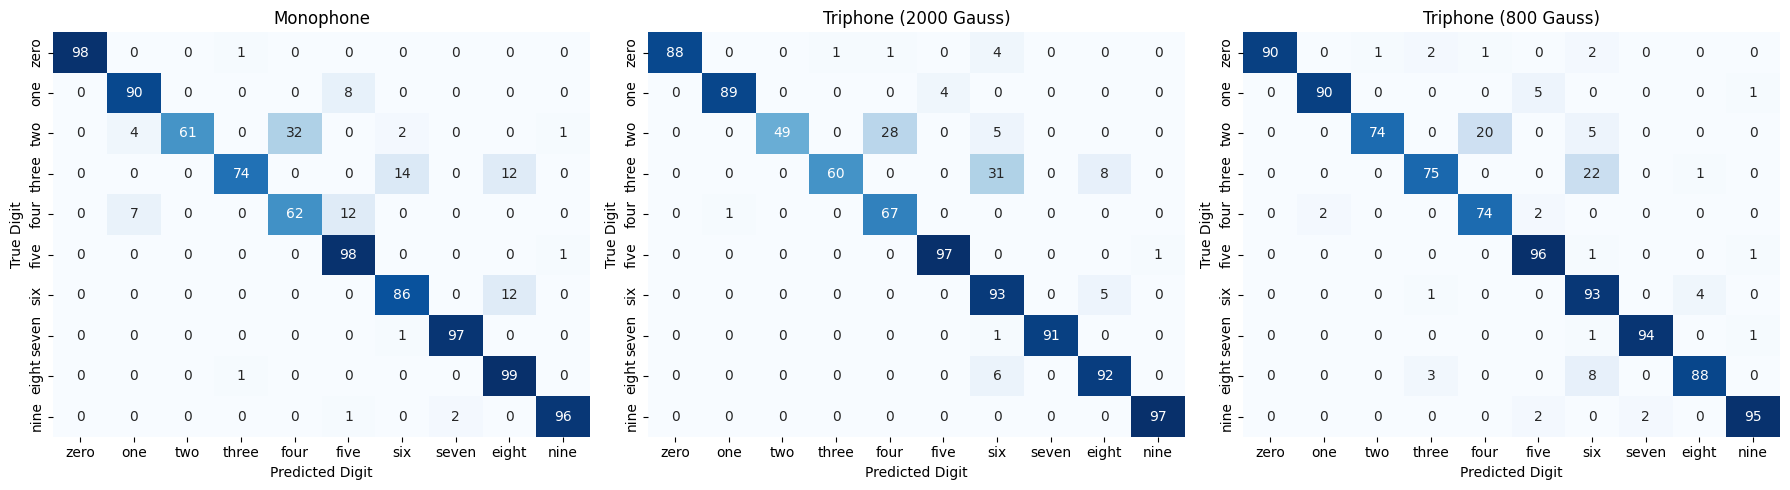

In [119]:
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

recipe_path = "/mnt/disk1/ye/exp/speech/kaldi/egs/fsdd_demo/s5"
digits = ["zero", "one", "two", "three", "four", "five", "six", "seven", "eight", "nine"]

def get_hypotheses_and_refs(decode_dir):
    """
    Reads the 'per_utt' file generated by Kaldi's scoring script.
    This file contains the exact reference and hypothesis for every utterance,
    completely bypassing path and file parsing issues.
    """
    # Look for per_utt in either scoring/ or scoring_kaldi/
    per_utt_files = glob.glob(f"{recipe_path}/{decode_dir}/scoring*/wer_details/per_utt")
    if not per_utt_files:
        print(f"No per_utt file found in {decode_dir}")
        return {}, {}
        
    refs = {}
    hyps = {}
    
    with open(per_utt_files[0], 'r') as f:
        for line in f:
            parts = line.strip().split(maxsplit=2)
            if len(parts) < 3: continue
            utt_id = parts[0]
            field_type = parts[1] # 'ref', 'hyp', 'op', etc.
            text = parts[2]
            
            if field_type == "ref":
                refs[utt_id] = text
            elif field_type == "hyp":
                hyps[utt_id] = text
                
    return refs, hyps

def plot_confusion_matrix(decode_dir, title, ax):
    # 1. Get References and Hypotheses directly from per_utt
    refs, hyps = get_hypotheses_and_refs(decode_dir)
    
    if not hyps:
        ax.set_title(f"{title}\n(No Data)")
        ax.axis('off')
        return
        
    # DEBUG: Print first 5 predictions to verify
    if title == "Monophone":
        print(f"Sample predictions for {title}:")
        for i, (utt, hyp) in enumerate(hyps.items()):
            if i < 5:
                print(f"  {utt}: ref='{refs.get(utt)}' -> hyp='{hyp}'")
        print("-" * 50)
        
    # 2. Build Matrix
    matrix = np.zeros((len(digits), len(digits)), dtype=int)
    
    for utt_id, ref in refs.items():
        if ref not in digits: continue
        ref_idx = digits.index(ref)
        
        hyp = hyps.get(utt_id, "")
        hyp_words = hyp.split()
        
        # If the model predicted exactly one digit, map it. 
        if len(hyp_words) == 1 and hyp_words[0] in digits:
            hyp_idx = digits.index(hyp_words[0])
            matrix[ref_idx][hyp_idx] += 1
            
    # 3. Plot Heatmap
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Blues", 
                xticklabels=digits, yticklabels=digits, ax=ax, cbar=False)
    ax.set_xlabel("Predicted Digit")
    ax.set_ylabel("True Digit")
    ax.set_title(title)

# --- Generate the plots for all 3 models ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

plot_confusion_matrix("exp/mono0a/decode", "Monophone", axes[0])
plot_confusion_matrix("exp/tri1/decode", "Triphone (2000 Gauss)", axes[1])
plot_confusion_matrix("exp/tri1_small/decode", "Triphone (800 Gauss)", axes[2])

plt.tight_layout()
plt.show()

## Summary for your Students:

ဒီ Tutorial မှာတော့ Monophone နဲ့ Triphone မော်ဒယ်နှစ်ခုအကြား ဘယ်လိုမတူတာတွေရှိတယ်၊ data size က သေးရင်တော့ Triphone မော်ဒယ်က ရလဒ်နည်းနိုင်တယ်ဆိုတာကိုလည်း လက်တွေ့ လေ့လာခဲ့ကြပါတယ်။ ပြီးတော့ Assignment-4 နဲ့ ဆက်စပ်နေတဲ့ isolated digit ASR ကိုလည်း လုပ်တတ်သွားကြပြီလို့ ယုံကြည်ပါတယ်။    